#  ✨ ChurnGuard AI: Enterprise Customer Retention & Revenue Optimization System

###  ፣ Description
An AI-Powered Decision Support Framework for Predicting, Explaining, and Preventing Customer Churn in Telecom Operators.

---

##  ፅ Business Context

Telecom operators such as Ethio telecom and Safaricom manage millions of subscribers and face a critical challenge: **customer churn**.

Customer churn leads to:
- Revenue loss
- Increased acquisition cost
- Reduced customer lifetime value (CLTV)

---

##  ጳ Objective

Build a machine learning system to:

- Predict which customers are likely to churn
- Identify key drivers of churn
- Provide actionable insights for retention strategies

---

##  ፈ Key Business Questions

1. Which customers are likely to churn?
2. What factors influence churn?
3. Which customer segments are at risk?
4. How can the business reduce churn proactively?

**ChurnGuard AI — Business Understanding & Exploratory Data Analysis**

In [12]:
!pip install xgboost imbalanced-learn shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.4/235.4 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 73.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.2/300.2 MB 1.2 MB/s eta 0:00:00


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Settings
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

# 📊 Telco Customer Churn: Business Intelligence & Strategy Report

In [6]:
# 📦 Data Loading & Initial Cleaning

import pandas as pd
import numpy as np

# Updated URL to a reliable source for the Telco Churn dataset
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill missing values with median
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# Drop customerID (not useful for modeling)
if 'customerID' in df.columns:
    df.drop("customerID", axis=1, inplace=True)

# Display data
display(df.head())
df.info()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [7]:
# 💰 Business Metrics Baseline

# Convert churn to binary
df['Churn_Flag'] = df['Churn'].map({'Yes': 1, 'No': 0})

# 1. Churn Rate
churn_rate = df['Churn_Flag'].mean() * 100

# 2. Revenue at Risk (MonthlyCharges of churners)
revenue_at_risk = df[df['Churn_Flag'] == 1]['MonthlyCharges'].sum()

# 3. ARPU (Average Revenue Per User)
arpu_churn = df[df['Churn_Flag'] == 1]['MonthlyCharges'].mean()
arpu_retained = df[df['Churn_Flag'] == 0]['MonthlyCharges'].mean()

# Print results
print(f"📉 Overall Churn Rate: {churn_rate:.2f}%")
print(f"💰 Monthly Revenue at Risk: ${revenue_at_risk:,.2f}")
print(f"📊 ARPU (Churned Customers): ${arpu_churn:.2f}")
print(f"📊 ARPU (Retained Customers): ${arpu_retained:.2f}")

📉 Overall Churn Rate: 26.54%
💰 Monthly Revenue at Risk: $139,130.85
📊 ARPU (Churned Customers): $74.44
📊 ARPU (Retained Customers): $61.27


###  ፡ Business Metric Definitions

*   **Overall Churn Rate (26.54%)**: The percentage of customers who stopped their subscription. This is the primary KPI we aim to reduce.
*   **Monthly Revenue at Risk ($139,130.85)**: The total monthly billings lost from customers who churned. This represents the immediate financial impact.
*   **ARPU (Average Revenue Per User)**:
    *   **Churned ($74.44) vs. Retained ($61.27)**: Notice that churned customers have a **higher ARPU**. This indicates the business is disproportionately losing its most profitable, high-tier customers.

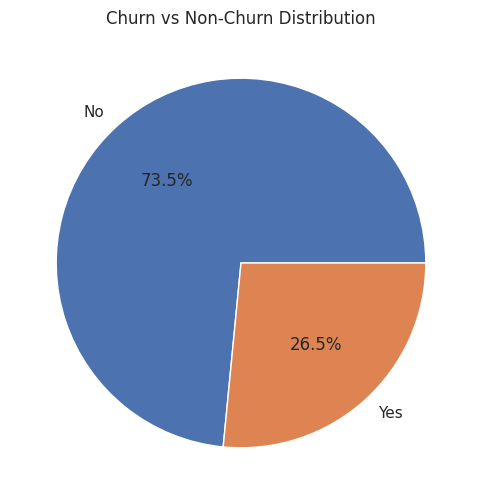

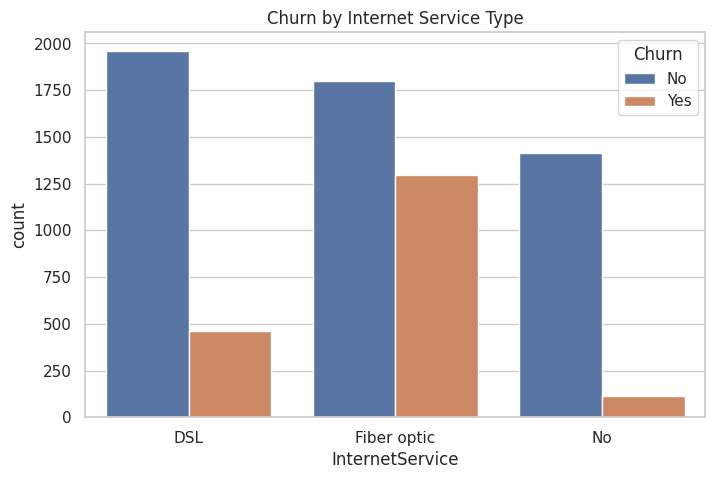

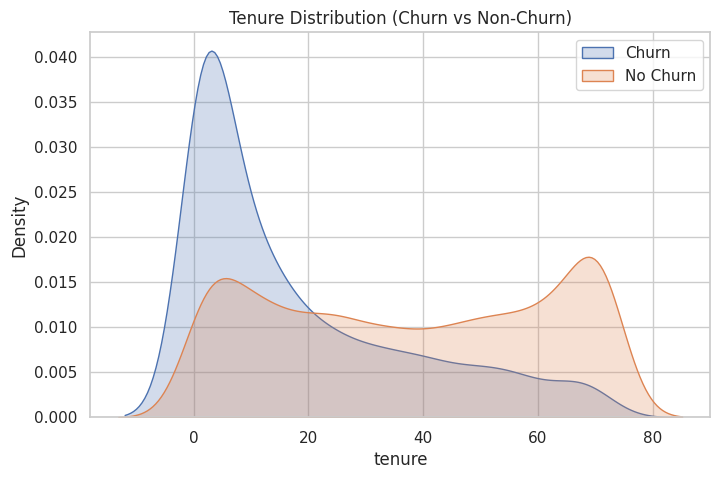

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# 📌 1. Churn Distribution (Pie Chart)
plt.figure(figsize=(6,6))
df['Churn'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title("Churn vs Non-Churn Distribution")
plt.ylabel("")
plt.show()


# 📌 2. Internet Service vs Churn
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='InternetService', hue='Churn')
plt.title("Churn by Internet Service Type")
plt.show()


# 📌 3. Tenure Distribution (Danger Zone)
plt.figure(figsize=(8,5))
sns.kdeplot(data=df[df['Churn']=="Yes"], x='tenure', label='Churn', fill=True)
sns.kdeplot(data=df[df['Churn']=="No"], x='tenure', label='No Churn', fill=True)
plt.title("Tenure Distribution (Churn vs Non-Churn)")
plt.legend()
plt.show()

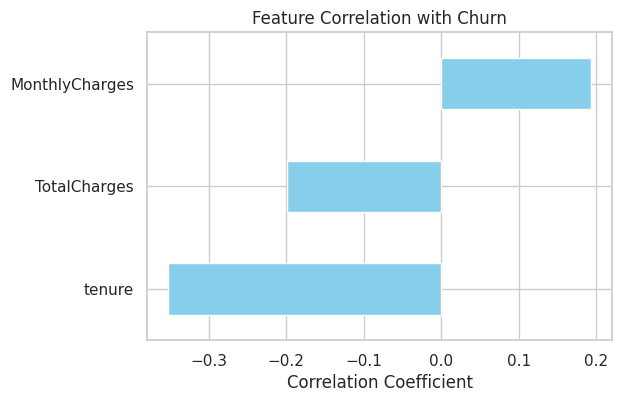

🔍 Insight: Features with higher absolute correlation are stronger churn predictors.


In [10]:
# Correlation Analysis

# Ensure df exists in local namespace or global
try:
    # Encode churn for correlation
    df_corr = df.copy()
    df_corr['Churn'] = df_corr['Churn'].map({'Yes': 1, 'No': 0})

    # Select numeric features
    numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']

    # Calculate correlation
    corr = df_corr[numeric_cols].corr()['Churn'].drop('Churn')

    # Plot
    plt.figure(figsize=(6,4))
    corr.sort_values().plot(kind='barh', color='skyblue')
    plt.title("Feature Correlation with Churn")
    plt.xlabel("Correlation Coefficient")
    plt.show()

    print("🔍 Insight: Features with higher absolute correlation are stronger churn predictors.")
except NameError:
    print("❌ Error: 'df' is not defined. Please run the 'Data Loading' cell at the top of the notebook first.")

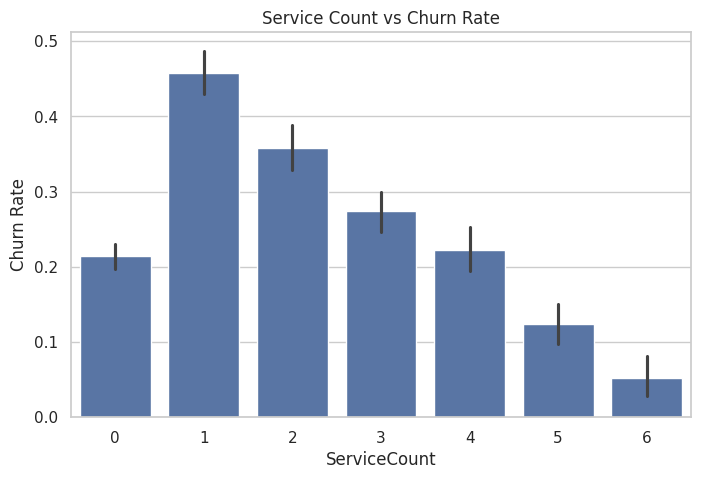

In [11]:
# Service Stickiness

services = [
    'OnlineSecurity','OnlineBackup','DeviceProtection',
    'TechSupport','StreamingTV','StreamingMovies'
]

# Convert Yes/No to 1/0
for col in services:
    df[col] = df[col].map({'Yes':1, 'No':0, 'No internet service':0})

# Create Service Count
df['ServiceCount'] = df[services].sum(axis=1)

# Plot churn vs service count
plt.figure(figsize=(8,5))
sns.barplot(x='ServiceCount', y='Churn_Flag', data=df)
plt.title("Service Count vs Churn Rate")
plt.ylabel("Churn Rate")
plt.show()

## 📊 Executive Insights for Stakeholders

### 🔥 Key Drivers of Churn:
1. Customers with **month-to-month contracts**
2. **High monthly charges**
3. Customers with **low tenure (early lifecycle stage)**

---

### 💰 Financial Impact:
- Significant **monthly revenue is at risk due to churn**
- High-value customers contribute disproportionately to revenue loss

---

### 📉 Behavioral Insights:
- The highest churn occurs in the **first 6 months** ("Danger Zone")
- Customers with fewer services are more likely to leave

---

### 💡 Strategic Implications:
- Promote **long-term contracts**
- Target **new customers early**
- Increase **service bundling (stickiness)**

---

## 🚀 Next Step

Based on these insights, the next phase will focus on:

👉 Feature Engineering  
👉 Predictive Modeling (XGBoost)  
👉 Explainability (SHAP)  
👉 Decision Engine for retention strategies

## ሴ 11. Data Persistence for Modeling

We save the cleaned and processed dataframe to a CSV file so it can be loaded in the next notebook for Feature Engineering and Modeling.

In [14]:
# Save for Notebook 02
df.to_csv("clean_telco_churn.csv", index=False)
print("✅ Dataset saved as 'clean_telco_churn.csv'")

✅ Dataset saved as 'clean_telco_churn.csv'


# ሩ Notebook 02: Feature Engineering & Modeling

Now that we have saved our clean data, we can load it to start the machine learning phase.

In [18]:
import pandas as pd

# Load the dataset saved from the previous step
df_ready = pd.read_csv('clean_telco_churn.csv')

# Display the first few rows and info to verify everything is correct
display(df_ready.head())
print(f"\n✅ Successfully loaded {len(df_ready)} rows for modeling.")

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_Flag,ServiceCount
0,Female,0,Yes,No,1,No,No phone service,DSL,0,1,...,0,0,Month-to-month,Yes,Electronic check,29.85,29.85,No,0,1
1,Male,0,No,No,34,Yes,No,DSL,1,0,...,0,0,One year,No,Mailed check,56.95,1889.50,No,0,2
2,Male,0,No,No,2,Yes,No,DSL,1,1,...,0,0,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,2
3,Male,0,No,No,45,No,No phone service,DSL,1,0,...,0,0,One year,No,Bank transfer (automatic),42.30,1840.75,No,0,3
4,Female,0,No,No,2,Yes,No,Fiber optic,0,0,...,0,0,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,0



✅ Successfully loaded 7043 rows for modeling.


## 💾 Exporting Artifacts to Google Drive

To ensure your work is persisted outside of the temporary Colab runtime, we will mount Google Drive and save our processed data and model.

In [20]:
from google.colab import drive
import os
import shutil

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Define the project path
project_folder = '/content/drive/My Drive/ChurnGuard_AI'

# 3. Create folder if it doesn't exist
if not os.path.exists(project_folder):
    os.makedirs(project_folder)
    print(f"✅ Created folder: {project_folder}")
else:
    print(f"📂 Folder already exists: {project_folder}")

# 4. Copy the dataset
shutil.copy('clean_telco_churn.csv', os.path.join(project_folder, 'clean_telco_churn.csv'))

# 5. Save the trained XGBoost model
model.save_model(os.path.join(project_folder, 'churn_model_xgb.json'))

print(f"🚀 Successfully dumped dataset and model to: {project_folder}")

Mounted at /content/drive
✅ Created folder: /content/drive/My Drive/ChurnGuard_AI
🚀 Successfully dumped dataset and model to: /content/drive/My Drive/ChurnGuard_AI
